# QRT benchmark versus the first internal Ridge model

### A paired comparison on identical date-grouped folds

This notebook isolates one historical question: did the first internal Ridge
model improve on the Ridge benchmark supplied by QRT?

Both pipelines are fitted on the same continuous target, evaluated on the same
rows and the same eight held-out date groups, and converted to classes with the
same rule: `score > 0`. The comparison is therefore paired by observation and
by date.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.cross_validation import CVConfig, ModelConfig, run_cv
from src.data import ChallengeDataLoader
from src.metrics import compare_oof
from src.pipelines import make_first_ridge_pipeline

COLORS = {
    "ink": "#183446",
    "qrt": "#8A99A6",
    "model": "#2A9D8F",
    "accent": "#E76F51",
    "gold": "#E9C46A",
    "grid": "#DCE4E8",
}
sns.set_theme(
    style="whitegrid",
    context="notebook",
    font_scale=1.05,
    rc={
        "axes.edgecolor": COLORS["grid"],
        "axes.labelcolor": COLORS["ink"],
        "axes.titlecolor": COLORS["ink"],
        "grid.color": COLORS["grid"],
        "grid.alpha": 0.65,
    },
)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 120})

X_train = ChallengeDataLoader.load_X_train()
y_train = ChallengeDataLoader.load_y_train()

## 1. Two reproducible pipelines

| Component | QRT Ridge benchmark | First internal Ridge model |
|---|---|---|
| Raw inputs | 20 returns, 20 signed volumes, turnover and `TS` | Eight returns, allocation and group |
| Derived inputs | Row summaries and date-level cross-sectional summaries | Allocation and group fixed effects; allocation-specific `RET_1` slopes |
| Missing values | Replaced with zero | Median imputation learned in the training fold |
| Scaling | None | Standardization learned in the training fold |
| Estimator | `Ridge(alpha=1)` | `Ridge(alpha=100, solver="lsqr")` |

The QRT feature builder below reproduces the supplied benchmark. The internal
model reuses the same standard `ColumnTransformer` as the retained classifier;
only the final estimator and target differ.

In [2]:
RETURN_FEATURES = tuple(f"RET_{lag}" for lag in range(1, 21))
VOLUME_FEATURES = tuple(f"SIGNED_VOLUME_{lag}" for lag in range(1, 21))
AVERAGE_WINDOWS = (3, 5, 10, 15, 20)
STD_WINDOWS = (20,)


class QRTFeatureBuilder(BaseEstimator, TransformerMixin):
    '''Reproduce the features in the supplied QRT Ridge benchmark.'''

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        frame = X.copy()
        for window in AVERAGE_WINDOWS:
            feature = f"AVERAGE_PERF_{window}"
            frame[feature] = frame[list(RETURN_FEATURES[:window])].mean(axis=1)
            frame[f"ALLOCATIONS_AVERAGE_PERF_{window}"] = frame.groupby("TS")[
                feature
            ].transform("mean")
        for window in STD_WINDOWS:
            feature = f"STD_PERF_{window}"
            frame[feature] = frame[list(RETURN_FEATURES[:window])].std(axis=1)
            frame[f"ALLOCATIONS_STD_PERF_{window}"] = frame.groupby("TS")[
                feature
            ].transform("mean")

        features = [*RETURN_FEATURES, *VOLUME_FEATURES, "MEDIAN_DAILY_TURNOVER"]
        features += [f"AVERAGE_PERF_{window}" for window in AVERAGE_WINDOWS]
        features += [f"ALLOCATIONS_AVERAGE_PERF_{window}" for window in AVERAGE_WINDOWS]
        features += [f"STD_PERF_{window}" for window in STD_WINDOWS]
        features += [f"ALLOCATIONS_STD_PERF_{window}" for window in STD_WINDOWS]
        return frame[features].fillna(0)


qrt_pipeline = Pipeline(
    [("features", QRTFeatureBuilder()), ("ridge", Ridge(alpha=1.0))]
)
first_model_pipeline = make_first_ridge_pipeline()

## 2. Shared validation protocol

Unique `TS` values are shuffled once with `random_state=0` and assigned to eight
folds. Every row from a date remains in the same fold. Each complete pipeline is
cloned and refitted from scratch, so learned preprocessing never crosses the
train/validation boundary.

The fold identifiers are exchangeable labels rather than a chronological
sequence.

In [3]:
cv_config = CVConfig(n_splits=8, shuffle=True, random_state=0)

qrt_result = run_cv(
    X_train,
    y_train,
    ModelConfig(
        model=qrt_pipeline,
        regression=True,
    ),
    cv_config,
)
first_model_result = run_cv(
    X_train,
    y_train,
    ModelConfig(
        model=first_model_pipeline,
        regression=True,
    ),
    cv_config,
)

## 3. Out-of-fold performance

Accuracy is the challenge metric after thresholding the continuous Ridge score
at zero. The positive prediction rate is shown alongside it because two models
can obtain similar accuracy with materially different class balances.

In [4]:
def result_row(label, result):
    return {
        "model": label,
        "OOF accuracy": result.mean_accuracy,
        "predicted positive rate": result.oof_results["prediction"].mean(),
    }


performance = pd.DataFrame(
    [
        result_row("QRT Ridge benchmark", qrt_result),
        result_row("First internal Ridge model", first_model_result),
    ]
)
performance.style.hide(axis="index").format(
    {
        "OOF accuracy": "{:.2%}",
        "predicted positive rate": "{:.2%}",
    }
).set_caption("Performance on the complete OOF row set")

model,OOF accuracy,predicted positive rate
QRT Ridge benchmark,51.97%,56.37%
First internal Ridge model,52.47%,55.13%


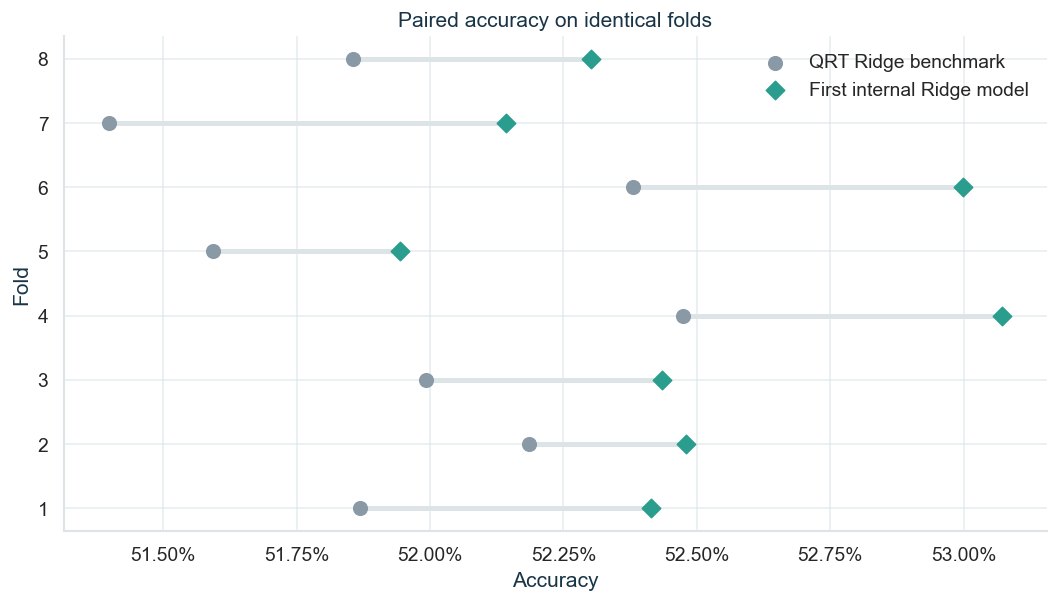

fold,QRT Ridge benchmark,First internal Ridge model
1,51.87%,52.41%
2,52.18%,52.48%
3,51.99%,52.43%
4,52.47%,53.07%
5,51.59%,51.94%
6,52.38%,53.00%
7,51.40%,52.14%
8,51.85%,52.30%


In [5]:
fold_accuracy = pd.DataFrame(
    {
        "fold": [fold.fold_id for fold in qrt_result.fold_results],
        "QRT Ridge benchmark": [fold.valid_metrics["accuracy"] for fold in qrt_result.fold_results],
        "First internal Ridge model": [
            fold.valid_metrics["accuracy"] for fold in first_model_result.fold_results
        ],
    }
)

fig, ax = plt.subplots(figsize=(9, 5.2))
for row in fold_accuracy.itertuples(index=False):
    ax.plot(
        [row[1], row[2]],
        [row.fold, row.fold],
        color=COLORS["grid"],
        linewidth=3,
        zorder=1,
    )
ax.scatter(
    fold_accuracy["QRT Ridge benchmark"],
    fold_accuracy["fold"],
    color=COLORS["qrt"],
    s=65,
    label="QRT Ridge benchmark",
    zorder=2,
)
ax.scatter(
    fold_accuracy["First internal Ridge model"],
    fold_accuracy["fold"],
    color=COLORS["model"],
    marker="D",
    s=60,
    label="First internal Ridge model",
    zorder=3,
)
ax.set(title="Paired accuracy on identical folds", xlabel="Accuracy", ylabel="Fold", yticks=fold_accuracy["fold"])
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

fold_accuracy.style.hide(axis="index").format(
    {"QRT Ridge benchmark": "{:.2%}", "First internal Ridge model": "{:.2%}"}
).set_caption("Fold-by-fold paired accuracy")

> **Result.** The first internal Ridge model reaches **52.47%** OOF
> accuracy, compared with **51.97%** for the QRT Ridge benchmark. It improves on
> the benchmark in all eight folds. Its positive prediction rate is also closer
> to the observed 50.72% prevalence, although it remains above it.

## 4. Paired comparison by date

The row-level gain is computed before aggregation, so the two correctness
indicators are paired on exactly the same observations. Date-level gains then
show how broadly the aggregate improvement is distributed.

The reference band below is the mean paired gain plus or minus 1.96 times the
simple standard error across date-level gains. It is a descriptive stability
summary, not an econometric confidence interval under two-way panel dependence.

In [6]:
paired = compare_oof(
    first_model_result.oof_results,
    qrt_result.oof_results,
    group="TS",
)

paired_summary = pd.DataFrame(
    {
        "metric": [
            "Row-weighted accuracy gain",
            "Mean date-level gain",
            "Descriptive date-level standard error",
            "Descriptive 95% reference band",
            "Dates won",
            "Dates tied",
            "Dates lost",
        ],
        "value": [
            f"{paired['mean_accuracy_gain']:.2%}",
            f"{paired['group_mean_gain']:.2%}",
            f"{paired['group_gain_standard_error']:.2%}",
            f"[{paired['ci95_low']:.2%}, {paired['ci95_high']:.2%}]",
            f"{paired['groups_won']:,}",
            f"{paired['groups_tied']:,}",
            f"{paired['groups_lost']:,}",
        ],
    }
)
paired_summary.style.hide(axis="index").set_caption("Paired OOF comparison")

metric,value
Row-weighted accuracy gain,0.50%
Mean date-level gain,0.54%
Descriptive date-level standard error,0.09%
Descriptive 95% reference band,"[0.33%, 0.68%]"
Dates won,"1,345"
Dates tied,125
Dates lost,"1,052"


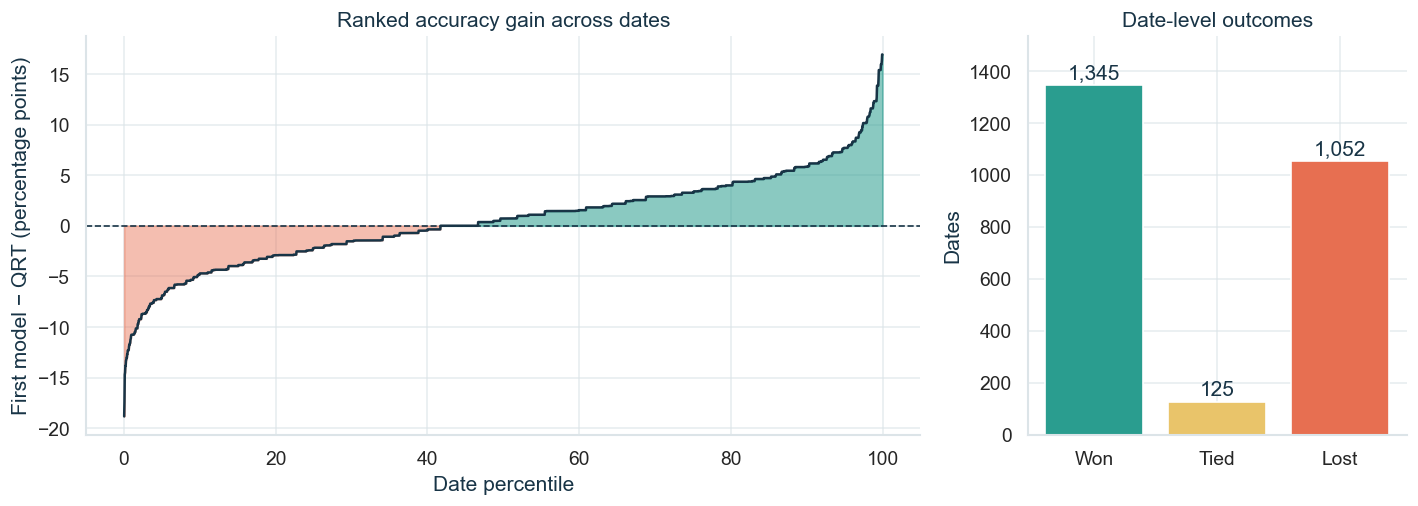

In [7]:
row_gain = (
    first_model_result.oof_results["is_correct"]
    - qrt_result.oof_results["is_correct"]
)
date_gain = row_gain.groupby(first_model_result.oof_results["TS"]).mean().sort_values()
date_percentile = 100 * (np.arange(len(date_gain)) + 0.5) / len(date_gain)
gain_pp = 100 * date_gain.to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [2.2, 1]})
axes[0].plot(date_percentile, gain_pp, color=COLORS["ink"], linewidth=1.5)
axes[0].fill_between(date_percentile, 0, gain_pp, where=gain_pp >= 0, color=COLORS["model"], alpha=0.55)
axes[0].fill_between(date_percentile, 0, gain_pp, where=gain_pp < 0, color=COLORS["accent"], alpha=0.45)
axes[0].axhline(0, color=COLORS["ink"], linestyle="--", linewidth=1)
axes[0].set(title="Ranked accuracy gain across dates", xlabel="Date percentile", ylabel="First model − QRT (percentage points)")

outcomes = pd.DataFrame(
    {
        "outcome": ["Won", "Tied", "Lost"],
        "dates": [paired["groups_won"], paired["groups_tied"], paired["groups_lost"]],
        "color": [COLORS["model"], COLORS["gold"], COLORS["accent"]],
    }
)
axes[1].bar(outcomes["outcome"], outcomes["dates"], color=outcomes["color"])
for position, value in enumerate(outcomes["dates"]):
    axes[1].text(position, value + 25, f"{value:,}", ha="center", color=COLORS["ink"])
axes[1].set(title="Date-level outcomes", xlabel="", ylabel="Dates", ylim=(0, outcomes["dates"].max() * 1.14))
plt.tight_layout()
plt.show()

## 5. Conclusion

The first internal Ridge model improves row-level OOF accuracy by **0.50
percentage points** relative to the QRT Ridge benchmark. The gain is positive
in every fold and on **1,345 of 2,522 dates**, with 125 ties and 1,052 losses.
The descriptive date-level reference band is approximately **[0.33, 0.68]
percentage points**.

This establishes the first internal Ridge model as the stronger controlled
Ridge benchmark. It does not establish statistical significance under panel
dependence, and it is intentionally separate from the retained logistic model
presented in the previous notebook.